In [1]:
import pandas as pd
import pathlib
import rootutils
import torch
import seaborn as sns

rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
root = pathlib.Path(rootutils.find_root("."))

In [2]:
import torch

x = torch.randn(6 * 39, 4)
x = x.expand(6, -1, -1).permute(1, 0, 2).unsqueeze(-3)
print(x.shape)
y = torch.randn(6 * 39, 12288)
y = y.unflatten(-1, (512, 6, 4))
print(y.shape)

z = y + x
x[0, 0]

torch.Size([234, 1, 6, 4])
torch.Size([234, 512, 6, 4])


tensor([[-1.0910, -0.6141, -0.3740, -0.2606],
        [-1.0910, -0.6141, -0.3740, -0.2606],
        [-1.0910, -0.6141, -0.3740, -0.2606],
        [-1.0910, -0.6141, -0.3740, -0.2606],
        [-1.0910, -0.6141, -0.3740, -0.2606],
        [-1.0910, -0.6141, -0.3740, -0.2606]])

In [3]:
from src.core.models.components import MLP
from typing import List

class ContentDecoderFrequencyBandSumOffset(torch.nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        out_height: int,
        out_width: int,
        layer_sizes: List[int],
        activation: str,
        dropout_prob: float,
    ) -> None:
        super().__init__()
        assert layer_sizes[-1] == in_channels * out_height * out_width, \
            f"MLP output dimension ({layer_sizes_1[-1]}) must match conv ({in_channels} * {out_height} * {out_width})"
        self.in_channels = in_channels
        self.out_height = out_height
        self.out_width = out_width
        self.mlp_1 = MLP(layer_sizes, activation, dropout_prob)
        self.mlp_2 = MLP([self.out_width, self.out_width * 4, self.out_width * 4, self.out_width], activation, dropout_prob)
        self.conv_up = torch.nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        z, z_glob = z[:, :-self.out_width], z[:, -self.out_width:]
        x = self.mlp_1(z)
        x = x.unflatten(-1, (self.in_channels, self.out_height, self.out_width))
        x = self.conv_up(x)
        y = self.mlp_2(z_glob)
        y = y.expand(self.out_height, -1, -1).transpose(0, 1).unsqueeze(-3)
        return x + y

model = ContentDecoderFrequencyBandSumOffset(
    in_channels=128,
    out_channels=512,
    layer_sizes=[128, 768, 3072],
    out_width=4,
    out_height=6,
    activation="LEAK",
    dropout_prob=0.1,
)

z = torch.randn(6 * 39, 128 + 4)
model(z).shape

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


torch.Size([234, 512, 6, 4])

In [4]:
class ContentDecoderFrequencyBandStackOffset(torch.nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        out_height: int,
        out_width: int,
        layer_sizes: List[int],
        activation: str,
        dropout_prob: float,
    ) -> None:
        super().__init__()
        assert layer_sizes[-1] == in_channels * out_height * out_width, \
            f"MLP output dimension ({layer_sizes_1[-1]}) must match conv ({in_channels} * {out_height} * {out_width})"
        self.in_channels = in_channels
        self.out_height = out_height
        self.out_width = out_width
        self.mlp_1 = MLP(layer_sizes, activation, dropout_prob)
        self.mlp_2 = MLP([self.out_width, self.out_width * 4, self.out_width * 4, self.out_width], activation, dropout_prob)
        self.conv_up = torch.nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.conv_combine = torch.nn.Conv2d(out_channels + 1, out_channels, kernel_size=1)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        z, z_glob = z[:, :-self.out_width], z[:, -self.out_width:]
        x = self.mlp_1(z)
        x = x.unflatten(-1, (self.in_channels, self.out_height, self.out_width))
        x = self.conv_up(x)
        y = self.mlp_2(z_glob)
        y = y.expand(self.out_height, -1, -1).transpose(0, 1).unsqueeze(-3)
        return self.conv_combine(torch.cat([x, y], dim=-3))

model = ContentDecoderFrequencyBandStackOffset(
    in_channels=128,
    out_channels=512,
    layer_sizes=[128, 768, 3072],
    out_width=4,
    out_height=6,
    activation="LEAK",
    dropout_prob=0.1,
)
z = torch.randn(6 * 39, 128 + 4)
model(z).shape

torch.Size([234, 512, 6, 4])

In [5]:
model.conv_combine.weight.shape

torch.Size([512, 513, 1, 1])

In [19]:
from src.core.data.sounding_out_chorus import SoundingOutChorus
from src.core.transforms.translation import translation_1d as translation
from src.core.models.sivae import SIVAE
from src.core.models.vae import VAE

data = SoundingOutChorus("/its/home/kag25/data/sounding_out", test=True)

checkpoint_dir = pathlib.Path("/its/home/kag25/models/v2/")
model_name = "sivae/grim-dexter/"
checkpoint_path = "step=180000.ckpt"
model = SIVAE.load_from_checkpoint(checkpoint_dir / model_name / checkpoint_path, map_location="cuda").eval()

def cnn_decode(model, U: torch.Tensor, delta: torch.Tensor) -> torch.Tensor:
    bs, seq, _ = delta.size()
    U = U.flatten(end_dim=1)
    Us = [U]
    for i, block in enumerate(model.feature_decoder.blocks):
        if model.translation_idx == i:
            U = U.transpose(-1, -2).contiguous()
            U = model.translation(U, delta.view(bs * seq), mode=model.translation_mode)
            U = U.transpose(-1, -2).contiguous()
        if i == len(model.feature_decoder.blocks) - 1 and model.translation_idx != -1:
            U = U.unflatten(0, (bs, seq)).transpose(1, 2)
            U = U.flatten(start_dim=2, end_dim=3)
        U = block(U)
        Us.append(U)
    return U, Us

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

(torch.Size([39, 512, 6, 4]),
 torch.Size([39, 256, 12, 8]),
 torch.Size([39, 128, 24, 16]),
 torch.Size([39, 64, 48, 32]),
 torch.Size([39, 32, 96, 64]),
 torch.Size([1, 1, 7488, 64]))

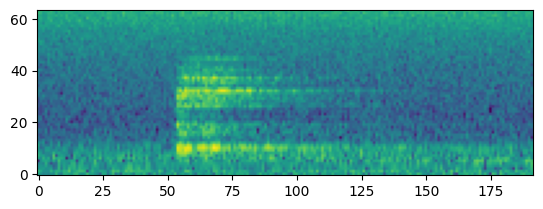

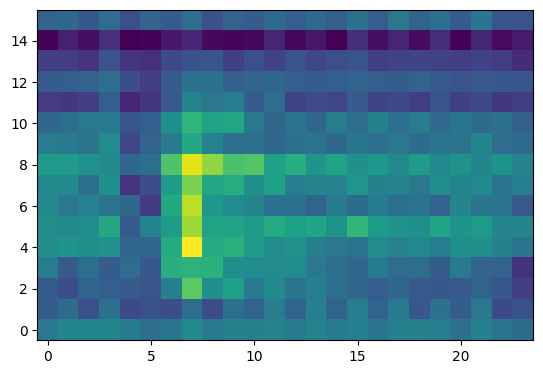

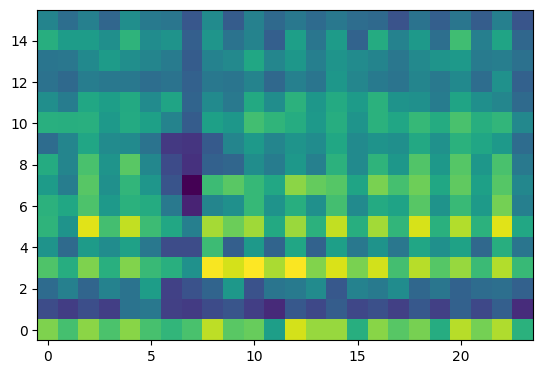

In [46]:
from matplotlib import pyplot as plt

file_i = 4
frame_i = 5

with torch.no_grad():
    x = data[file_i][0].unsqueeze(0)
    x = x.to("cuda")
    x = model.pre_process(x)
    q_z, (theta, *_) = model.encode(x)
    theta = torch.zeros_like(theta)
    mu_z, _ = q_z.chunk(2, dim=-1)
    U = model.content_decoder(mu_z.flatten(end_dim=1)).unflatten(0, (mu_z.size(0), mu_z.size(1)))
    _, Us = cnn_decode(model, U, theta / torch.pi)
    
Us[0].shape, Us[1].shape, Us[2].shape, Us[3].shape, Us[4].shape, Us[5].shape

plt.imshow(x[:, :, frame_i*192:(frame_i+1)*192].cpu().squeeze().T, origin="lower")
plt.show()

plt.imshow(Us[2][frame_i][0].cpu().t(), origin="lower")
plt.show()

plt.imshow(Us[2][frame_i][1].cpu().t(), origin="lower")
plt.show()


In [ ]:
class FrequencyBandOffsetDecoder(torch.nn.Module):
    def __init__(
        self,
        layer_sizes:
        num_bands: int,
    ) -> None:
        super().__init__()
        assert layer_sizes[-1] == in_channels * out_height * out_width, \
            f"MLP output dimension ({layer_sizes_1[-1]}) must match conv ({in_channels} * {out_height} * {out_width})"
        self.in_channels = in_channels
        self.out_height = out_height
        self.out_width = out_width
        self.mlp_1 = MLP(layer_sizes, activation, dropout_prob)
        self.mlp_2 = MLP([self.out_width, self.out_width * 4, self.out_width * 4, self.out_width], activation, dropout_prob)
        self.conv_up = torch.nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.conv_combine = torch.nn.Conv2d(out_channels + 1, out_channels, kernel_size=1)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        z, z_glob = z[:, :-self.out_width], z[:, -self.out_width:]
        x = self.mlp_1(z)
        x = x.unflatten(-1, (self.in_channels, self.out_height, self.out_width))
        x = self.conv_up(x)
        y = self.mlp_2(z_glob)
        y = y.expand(self.out_height, -1, -1).transpose(0, 1).unsqueeze(-3)
        return self.conv_combine(torch.cat([x, y], dim=-3))

model = ContentDecoderFrequencyBandStackOffset(
    in_channels=128,
    out_channels=512,
    layer_sizes=[128, 768, 3072],
    out_width=4,
    out_height=6,
    activation="LEAK",
    dropout_prob=0.1,
)
z = torch.randn(6 * 39, 128 + 4)
model(z).shape